# Power-law analysis of a single process-mining event log

This notebook performs an initial discrete power-law analysis for **one** event log
using the Python [`powerlaw`](https://github.com/jeffalstott/powerlaw) package
(Clauset–Shalizi–Newman style fitting and model comparison).

Observations are **occurrence frequencies of distinct trace variants**
(one frequency per variant). The notebook does **not** expand the data to one
row per case and does **not** treat ranks as observations.

Shared statistical helpers live in `utils.powerlaw`. This notebook
never imports from `cli/`.

## Environment setup (required before running)

Create and activate the Conda environment from the repository root:

```bash
conda env create -f environment.yml
conda activate process-mining-rfcs
```

If the environment already exists and you need to refresh dependencies:

```bash
conda env update -f environment.yml --prune
conda activate process-mining-rfcs
```

**Select the `process-mining-rfcs` Jupyter kernel** (not older kernels such as
`rfcs-in-process-mining`), then restart the kernel after creating or updating the
environment.

Do **not** install packages from within the notebook (no `pip install` / `conda install` cells).
`environment.yml` pins `matplotlib-inline==0.1.6` for compatibility with matplotlib 3.6.


## 0. Matplotlib / kernel compatibility check

Confirm that the active kernel uses a matplotlib / matplotlib-inline combination
compatible with this repository.


In [55]:
import sys
from importlib.metadata import version

import matplotlib

# Read matplotlib-inline version from package metadata so we never import it.
# Importing matplotlib_inline>=0.2 with matplotlib 3.6.x crashes
# (AttributeError: RcParams has no attribute '_get') before we can warn.
mpl_version_str = matplotlib.__version__
inline_version_str = version("matplotlib-inline")
mpl_version = tuple(int(part) for part in mpl_version_str.split(".")[:2])
inline_version = tuple(int(part) for part in inline_version_str.split(".")[:2])

print(f"Python: {sys.executable}")
print(f"matplotlib: {mpl_version_str}")
print(f"matplotlib-inline: {inline_version_str}")

# matplotlib-inline>=0.2 calls rcParams._get, which is absent in matplotlib 3.6.x.
if mpl_version < (3, 7) and inline_version >= (0, 2):
    raise RuntimeError(
        "Incompatible matplotlib / matplotlib-inline versions detected. "
        "You are likely on the old 'rfcs-in-process-mining' kernel. "
        "Select kernel 'process-mining-rfcs' (from environment.yml: "
        "matplotlib-inline==0.1.6 with matplotlib 3.6.x), then restart. "
        f"Current versions: matplotlib={mpl_version_str}, "
        f"matplotlib-inline={inline_version_str}."
    )

print("Matplotlib backend stack looks compatible.")


Python: /vol/home-vol2/promis/eberlenn/.conda/envs/process-mining-rfcs/bin/python
matplotlib: 3.6.3
matplotlib-inline: 0.1.6
Matplotlib backend stack looks compatible.


## 1. Imports and configuration

Configure the concept and log name. The default input is
`results/attachments/variants/BPIC12/attachments.csv.gz`.


In [56]:
import os
import sys
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import powerlaw

# Notebook lives under analyses/rfcs/; resolve repo root for imports and data paths.
REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / "utils").is_dir() and (candidate / "environment.yml").is_file():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError(
        f"Could not locate repository root from {Path.cwd().resolve()}. "
        "Open this notebook from within the process-mining-rfcs repository."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from utils.powerlaw import (
    DEFAULT_DOUBLY_BOUNDED_EXCLUDE_HEAD_VARIANTS,
    DISTRIBUTION_NAMES,
    DOUBLY_BOUNDED_POWER_LAW,
    FULL_RANGE_POWER_LAW,
    LOWER_BOUNDED_POWER_LAW,
    run_clauset_pipeline,
)
from utils.io import load_attachments
from utils.rfc import extract_frequency_counts

DOUBLY_BOUNDED_EXCLUDE_HEAD_VARIANTS = DEFAULT_DOUBLY_BOUNDED_EXCLUDE_HEAD_VARIANTS

def human_model_label(name: str) -> str:
    return name.replace("_", " ")


concept_name = "variants"
log_name = "BPIC12"

input_path = Path("results") / "attachments" / concept_name / log_name / "attachments.csv.gz"

resolved_input_path = input_path.resolve()
print(f"Resolved input path: {resolved_input_path}")

if not input_path.exists():
    raise FileNotFoundError(
        f"Attachments file not found for concept={concept_name!r}, "
        f"log={log_name!r}. Expected file at: {resolved_input_path}"
    )

print("Input file found.")


Resolved input path: /vol/tmp/eberlenn/process-mining-rfcs/results/variants/BPIC12/attachments.csv.gz
Input file found.


## 2. Load and inspect the attachments file

Load attachments with the existing repository helper `utils.io.load_attachments`,
then inspect the table before deriving frequencies.
In this repository, attachments files contain one row per case attachment with
`attachment_time`, `attachment_index`, and `node_id` (where `node_id` identifies
the trace variant for `concept_name="variants"`).


In [57]:
attachments_df = load_attachments(input_path)

print("Shape:", attachments_df.shape)
display(attachments_df.head())
print("Column names:", attachments_df.columns.tolist())
print("\nData types:")
display(attachments_df.dtypes.to_frame(name="dtype"))
print("Missing-value counts:")
display(attachments_df.isna().sum().to_frame(name="n_missing"))


Shape: (13087, 3)


,attachment_time,attachment_index,node_id
0,2011-10-01T08:11:46.420000+02:00,0,"('A_SUBMITTED+COMPLETE', 'A_PARTLYSUBMITTED+CO..."
1,2011-10-01T08:16:21.037000+02:00,1,"('A_SUBMITTED+COMPLETE', 'A_PARTLYSUBMITTED+CO..."
2,2011-10-01T12:09:30.362000+02:00,2,"('A_SUBMITTED+COMPLETE', 'A_PARTLYSUBMITTED+CO..."
3,2011-10-01T13:02:12.557000+02:00,3,"('A_SUBMITTED+COMPLETE', 'A_PARTLYSUBMITTED+CO..."
4,2011-10-01T14:54:56.346000+02:00,4,"('A_SUBMITTED+COMPLETE', 'A_PARTLYSUBMITTED+CO..."


Column names: ['attachment_time', 'attachment_index', 'node_id']

Data types:


,dtype
attachment_time,object
attachment_index,int64
node_id,object


Missing-value counts:


,n_missing
attachment_time,0
attachment_index,0
node_id,0


## 3. Derive one frequency per distinct variant

Power-law fitting requires **one occurrence frequency per distinct variant**,
not one row per case.

Use the existing helper `utils.rfc.extract_frequency_counts`, which aggregates
attachment `node_id` value counts into a one-dimensional frequency vector
(same approach as a PDF power-law fit). Wrap that vector in a
small dataframe so the frequency-column configuration and validation below stay explicit.


In [58]:
extracted_frequencies = extract_frequency_counts(attachments_df)
frequency_df = pd.DataFrame({"frequency": extracted_frequencies.astype(int)})

print(
    "Extracted variant frequencies with utils.rfc.extract_frequency_counts. "
    f"Resulting shape: {frequency_df.shape}"
)
display(frequency_df.head())


Extracted variant frequencies with utils.rfc.extract_frequency_counts. Resulting shape: (4366, 1)


,frequency
0,3429
1,1872
2,271
3,209
4,160


### Frequency-column configuration

**Edit the variable below** if your frequency table uses a different column name.


In [59]:
frequency_column = "frequency"


## 4. Validate frequencies and build the analysis array

Build a one-dimensional NumPy integer array `frequencies` (one positive integer per distinct variant).


In [60]:
frequencies = frequency_df[frequency_column].to_numpy(dtype=float)
if frequencies.ndim != 1 or frequencies.size == 0:
    raise ValueError("frequencies must be a non-empty 1-D array")
if not np.all(np.isfinite(frequencies)) or np.any(frequencies <= 0):
    raise ValueError("frequencies must be finite and positive")
if not np.allclose(frequencies, np.round(frequencies)):
    raise ValueError("frequencies must be integers")
frequencies = np.asarray(np.round(frequencies), dtype=int)

print(f"Validated frequencies array: n={frequencies.size}, dtype={frequencies.dtype}")
print(f"Min={frequencies.min()}, max={frequencies.max()}")


Validated frequencies array: n=4366, dtype=int64
Min=1, max=3429


## 5. Basic descriptive statistics

Summarise the variant-frequency distribution: number of cases, number of
variants, and the concentration of rare (singleton / low-frequency) variants.


In [61]:
n_cases = int(frequencies.sum())
n_variants = int(frequencies.size)
n_singletons = int(np.sum(frequencies == 1))
singleton_share = n_singletons / n_variants if n_variants else 0.0
descriptive_stats = pd.DataFrame(
    [
        {
            "n_cases": n_cases,
            "n_variants": n_variants,
            "n_singletons": n_singletons,
            "singleton_share": singleton_share,
            "min_frequency": int(frequencies.min()),
            "max_frequency": int(frequencies.max()),
        }
    ]
)
display(descriptive_stats)


,n_cases,n_variants,min_frequency,max_frequency,mean_frequency,median_frequency,n_singletons,singleton_share,n_at_most_five,at_most_five_share
0,13087,4366,1,3429,2.997481,1.0,3754,0.859826,4246,0.972515


## 6. Rank-frequency curve (RFC) and exploratory PDF / CCDF

Sort frequencies in decreasing order to obtain the trace-variant rank-frequency
curve. A roughly straight appearance on log–log axes is **suggestive** of heavy
tails, but is **not** evidence of a power law. This notebook therefore does **not**
fit a linear regression in log–log space or report an $R^2$ value.

The empirical PDF and CCDF below are shown for the full frequency sample, still
**without** a fitted power-law overlay.


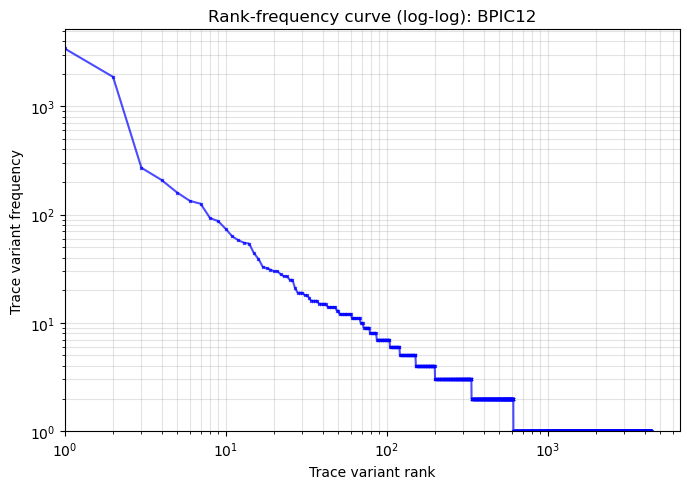

In [62]:
ranked_frequencies = np.sort(frequencies)[::-1].astype(int)
ranks = np.arange(1, ranked_frequencies.size + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    ranks,
    ranked_frequencies,
    color="blue",
    marker="x",
    linestyle="-",
    markersize=2,
    alpha=0.7,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(left=1)
ax.set_ylim(bottom=1)
ax.set_xlabel("Trace variant rank")
ax.set_ylabel("Trace variant frequency")
ax.set_title(f"Rank-frequency curve (log-log): {log_name}")
ax.grid(True, which="both", alpha=0.35)
fig.tight_layout()
plt.show()


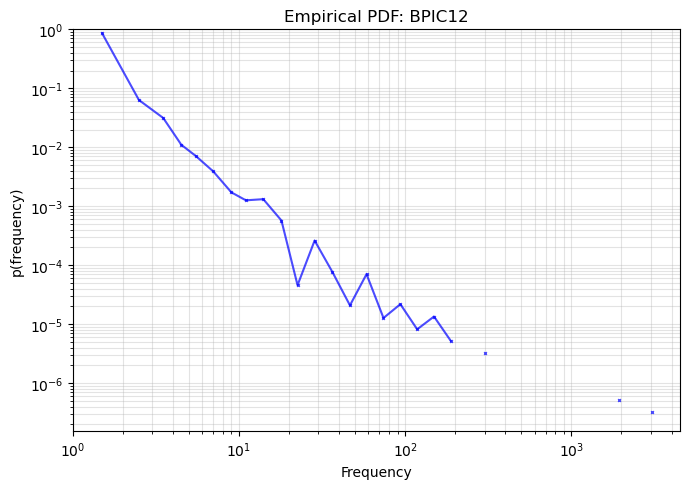

In [63]:
fig, ax = plt.subplots(figsize=(7, 5))
powerlaw.plot_pdf(
    frequencies,
    ax=ax,
    color="blue",
    marker="x",
    linestyle="-",
    markersize=2,
    alpha=0.7,
)
ax.set_xlim(left=1)
ax.set_ylim(top=1)
ax.set_xlabel("Frequency")
ax.set_ylabel("p(frequency)")
ax.set_title(f"Empirical PDF: {log_name}")
ax.grid(True, which="both", alpha=0.35)
fig.tight_layout()
plt.show()


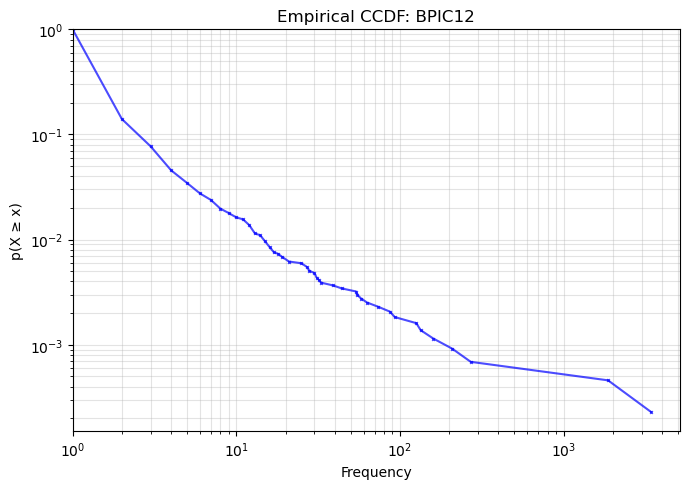

In [64]:
fig, ax = plt.subplots(figsize=(7, 5))
powerlaw.plot_ccdf(
    frequencies,
    ax=ax,
    color="blue",
    marker="x",
    linestyle="-",
    markersize=2,
    alpha=0.7,
)
ax.set_xlim(left=1)
ax.set_ylim(top=1)
ax.set_xlabel("Frequency")
ax.set_ylabel("p(X ≥ x)")
ax.set_title(f"Empirical CCDF: {log_name}")
ax.grid(True, which="both", alpha=0.35)
fig.tight_layout()
plt.show()


## 7. Fit three discrete power-law variants

Run `run_clauset_pipeline` once per model (full-range, lower-bounded, doubly-bounded).
Each call validates → MLE → bootstrap GOF (reusing the empirical fit) → LLR → classify.


In [65]:
# While developing, reduce n_bootstraps (e.g. to 100) for faster iteration.
n_bootstraps = 100
random_seed = 42
significance_level = 0.10
minimum_fitted_types = 50

print(
    "Methodological choices:",
    f"significance_level={significance_level},",
    f"minimum_fitted_types={minimum_fitted_types},",
    f"DOUBLY_BOUNDED_EXCLUDE_HEAD_VARIANTS={DOUBLY_BOUNDED_EXCLUDE_HEAD_VARIANTS}",
)

pipeline_results = {}
evaluations = {}
gof_rows_by_dist = {}
for name in DISTRIBUTION_NAMES:
    result = run_clauset_pipeline(
        frequencies,
        model=name,
        log_name=log_name,
        input_path=str(input_path),
        discrete=True,
        n_bootstraps=n_bootstraps,
        random_seed=random_seed,
        significance_level=significance_level,
        minimum_fitted_types=minimum_fitted_types,
        doubly_bounded_exclude_head_variants=DOUBLY_BOUNDED_EXCLUDE_HEAD_VARIANTS,
    )
    pipeline_results[name] = result
    evaluations[name] = result.get("evaluation")
    gof_rows_by_dist[name] = result.get("gof_rows", [])

db_candidate_fits = []  # not exposed by lean pipeline; plots use selected evaluation only
print("Finished Clauset pipelines for:", ", ".join(DISTRIBUTION_NAMES))


Methodological choices: significance_level=0.1, minimum_fitted_variants=50, minimum_orders_of_magnitude=1.0, DOUBLY_BOUNDED_EXCLUDE_HEAD_VARIANTS=(0, 1, 2, 3, 5, 10)


/vol/home-vol2/promis/eberlenn/.conda/envs/process-mining-rfcs/lib/python3.10/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/vol/home-vol2/promis/eberlenn/.conda/envs/process-mining-rfcs/lib/python3.10/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution power_law.
  warnings.warn(f"No valid fits found for distribution {self.name}.")
/vol/home-vol2/promis/eberlenn/.conda/envs/process-mining-rfcs/lib/python3.10/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


,distribution,fit_valid,xmin,xmax,pathology_flags,note,alpha,KS_D,n_fitted_variants,log_range,gof_p,gof_kind,alpha_at_boundary,doubly_bounded_exclude_head_variants,actual_excluded_variants
0,full_range_power_law,False,1.0,NaN,"[alpha_at_parameter_boundary, ks_d_pathological]",fit failed; alpha and downstream findings supp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lower_bounded_power_law,True,4.0,NaN,NaN,NaN,2.048576,0.032244,199.0,2.933107,0.702970,fixed_cutoffs,False,NaN,NaN
2,doubly_bounded_power_law,True,4.0,271.0,NaN,NaN,2.064377,0.029278,197.0,1.830909,0.623762,selection_repeating,False,2.0,2.0


,log_name,xmin,xmax,alpha,KS_D,n_fitted_variants,fitted_variant_share,fitted_case_share,log_range,gof_p,n_success,n_failed,alpha_at_boundary,fit_valid,gof_kind,doubly_bounded_exclude_head_variants,actual_excluded_variants,selected
0,BPIC12,4.0,271.0,2.064377,0.029278,197,0.045121,0.234508,1.830909,0.623762,100,0,False,True,selection_repeating,2,2,True


,doubly_bounded_exclude_head_variants,xmax,xmin,KS_D,n_fitted_variants,alpha
0,0,3429.0,4.0,0.033413,199,2.042764
1,1,1872.0,4.0,0.029908,198,2.074097
2,2,271.0,4.0,0.029278,197,2.064377
3,3,209.0,4.0,0.031434,196,2.075269
4,5,134.0,4.0,0.034390,194,2.090430
5,10,63.0,2.0,0.030910,602,2.281991


## 8. Distribution diagnostics (PDF and CCDF)

Compare the empirical distribution in each model's fitted region with the fitted
discrete power law (`powerlaw` PDF / CCDF helpers), one figure per model:

1. full-range power law
2. lower-bounded power law
3. doubly bounded power law

**Doubly bounded CCDF shape:** with a finite $x_{\max}$, the model is a
*truncated* power law. Its CCDF must reach 0 at $x_{\max}$, so on log–log axes
the red curve bends downward near the upper cutoff. That curvature is expected;
only an *untruncated* power-law CCDF is approximately linear on log–log scales.


Skipping PDF for full range power law: invalid fit (['alpha_at_parameter_boundary', 'ks_d_pathological']).


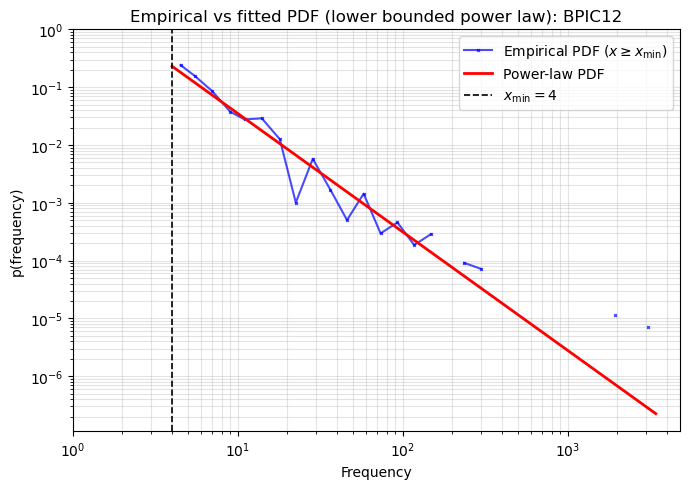

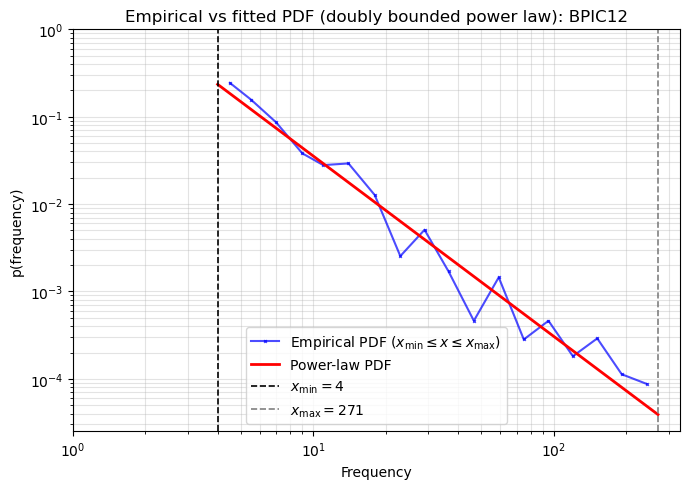

In [66]:
for name in DISTRIBUTION_NAMES:
    evaluation = evaluations.get(name)
    if evaluation is None:
        print(f"Skipping PDF for {human_model_label(name)}: no fit available.")
        continue
    if not bool(evaluation.get("fit_valid", True)):
        print(
            f"Skipping PDF for {human_model_label(name)}: "
            f"invalid fit ({evaluation.get('pathology_flags')})."
        )
        continue

    fit = evaluation["fit"]
    xmin_val = float(evaluation["xmin"])
    xmax_val = evaluation.get("xmax")
    has_xmax = xmax_val is not None and np.isfinite(float(xmax_val))

    fig, ax = plt.subplots(figsize=(7, 5))
    # Empirical + model on the fitted support (x >= xmin; also x <= xmax if set).
    fit.plot_pdf(
        ax=ax,
        color="blue",
        marker="x",
        linestyle="-",
        markersize=2,
        alpha=0.7,
        label=(
            rf"Empirical PDF ($x_{{\min}} \leq x \leq x_{{\max}}$)"
            if has_xmax
            else rf"Empirical PDF ($x \geq x_{{\min}}$)"
        ),
    )
    fit.power_law.plot_pdf(
        ax=ax,
        color="red",
        linestyle="-",
        linewidth=2.0,
        label="Power-law PDF",
    )
    ax.axvline(
        xmin_val,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=rf"$x_{{\min}}={xmin_val:g}$",
    )
    if has_xmax:
        xmax_f = float(xmax_val)
        ax.axvline(
            xmax_f,
            color="gray",
            linestyle="--",
            linewidth=1.2,
            label=rf"$x_{{\max}}={xmax_f:g}$",
        )
    ax.set_xlim(left=1)
    ax.set_ylim(top=1)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("p(frequency)")
    ax.set_title(f"Empirical vs fitted PDF ({human_model_label(name)}): {log_name}")
    ax.legend()
    ax.grid(True, which="both", alpha=0.35)
    fig.tight_layout()
    plt.show()


Skipping CCDF for full range power law: invalid fit (['alpha_at_parameter_boundary', 'ks_d_pathological']).


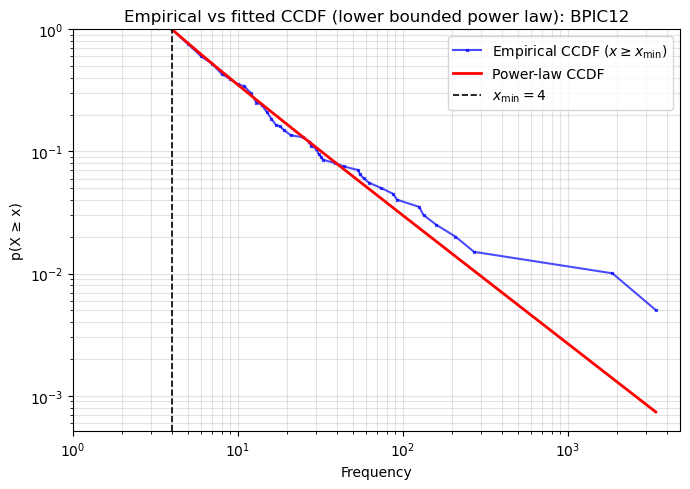

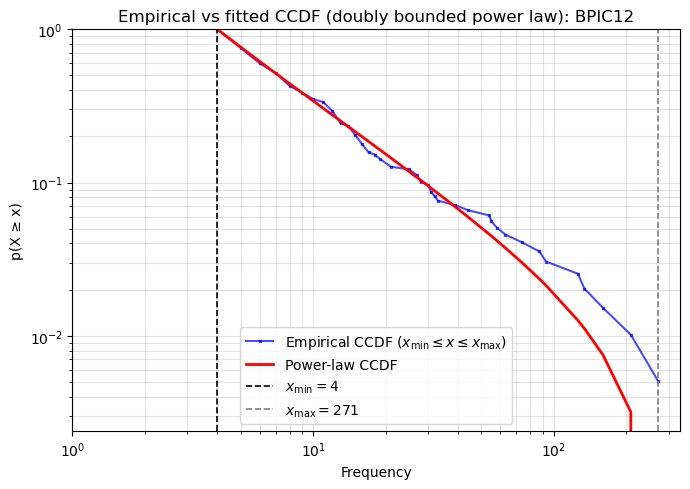

In [67]:
for name in DISTRIBUTION_NAMES:
    evaluation = evaluations.get(name)
    if evaluation is None:
        print(f"Skipping CCDF for {human_model_label(name)}: no fit available.")
        continue
    if not bool(evaluation.get("fit_valid", True)):
        print(
            f"Skipping CCDF for {human_model_label(name)}: "
            f"invalid fit ({evaluation.get('pathology_flags')})."
        )
        continue

    fit = evaluation["fit"]
    xmin_val = float(evaluation["xmin"])
    xmax_val = evaluation.get("xmax")
    has_xmax = xmax_val is not None and np.isfinite(float(xmax_val))

    fig, ax = plt.subplots(figsize=(7, 5))
    fit.plot_ccdf(
        ax=ax,
        color="blue",
        marker="x",
        linestyle="-",
        markersize=2,
        alpha=0.7,
        label=(
            rf"Empirical CCDF ($x_{{\min}} \leq x \leq x_{{\max}}$)"
            if has_xmax
            else rf"Empirical CCDF ($x \geq x_{{\min}}$)"
        ),
    )
    fit.power_law.plot_ccdf(
        ax=ax,
        color="red",
        linestyle="-",
        linewidth=2.0,
        label="Power-law CCDF",
    )
    ax.axvline(
        xmin_val,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=rf"$x_{{\min}}={xmin_val:g}$",
    )
    if has_xmax:
        xmax_f = float(xmax_val)
        ax.axvline(
            xmax_f,
            color="gray",
            linestyle="--",
            linewidth=1.2,
            label=rf"$x_{{\max}}={xmax_f:g}$",
        )
    ax.set_xlim(left=1)
    ax.set_ylim(top=1)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("p(X ≥ x)")
    ax.set_title(f"Empirical vs fitted CCDF ({human_model_label(name)}): {log_name}")
    ax.legend()
    ax.grid(True, which="both", alpha=0.35)
    fig.tight_layout()
    plt.show()


## 9. Mark the fitted region on the RFC

For each model, highlight the fitted frequency support on the RFC
($x \geq x_{\min}$, and $x \leq x_{\max}$ when doubly bounded).


Skipping RFC region for full range power law: invalid fit (['alpha_at_parameter_boundary', 'ks_d_pathological']).


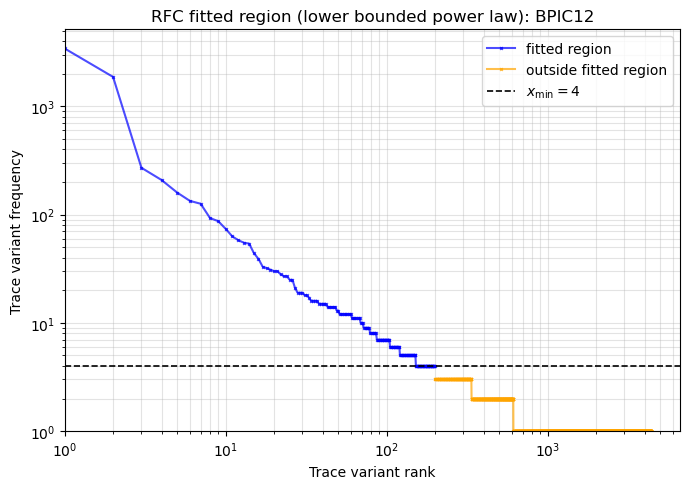

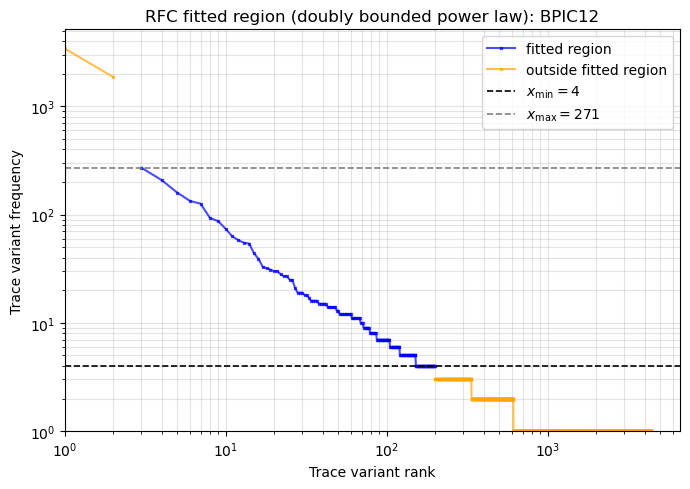

In [68]:
for name in DISTRIBUTION_NAMES:
    evaluation = evaluations.get(name)
    if evaluation is None:
        print(f"Skipping RFC region for {human_model_label(name)}: no fit available.")
        continue
    if not bool(evaluation.get("fit_valid", True)):
        print(
            f"Skipping RFC region for {human_model_label(name)}: "
            f"invalid fit ({evaluation.get('pathology_flags')})."
        )
        continue

    xmin_val = float(evaluation["xmin"])
    xmax_val = evaluation.get("xmax")
    has_xmax = xmax_val is not None and np.isfinite(float(xmax_val))
    xmax_f = float(xmax_val) if has_xmax else None

    in_fit = ranked_frequencies >= xmin_val
    if has_xmax:
        in_fit = in_fit & (ranked_frequencies <= xmax_f)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        ranks[in_fit],
        ranked_frequencies[in_fit],
        color="blue",
        marker="x",
        linestyle="-",
        markersize=2,
        alpha=0.7,
        label="fitted region",
    )
    # Plot each contiguous outside segment separately so the line does not
    # bridge across the fitted region (head above xmax + tail below xmin).
    outside_idx = np.flatnonzero(~in_fit)
    if outside_idx.size:
        segment_starts = np.r_[0, np.where(np.diff(outside_idx) > 1)[0] + 1]
        for seg_i, start in enumerate(segment_starts):
            end = (
                segment_starts[seg_i + 1]
                if seg_i + 1 < segment_starts.size
                else outside_idx.size
            )
            seg = outside_idx[start:end]
            ax.plot(
                ranks[seg],
                ranked_frequencies[seg],
                color="orange",
                marker="x",
                linestyle="-",
                markersize=2,
                alpha=0.7,
                label="outside fitted region" if seg_i == 0 else None,
            )
    ax.axhline(
        xmin_val,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=rf"$x_{{\min}}={xmin_val:g}$",
    )
    if has_xmax:
        ax.axhline(
            xmax_f,
            color="gray",
            linestyle="--",
            linewidth=1.2,
            label=rf"$x_{{\max}}={xmax_f:g}$",
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(left=1)
    ax.set_ylim(bottom=1)
    ax.set_xlabel("Trace variant rank")
    ax.set_ylabel("Trace variant frequency")
    ax.set_title(f"RFC fitted region ({human_model_label(name)}): {log_name}")
    ax.grid(True, which="both", alpha=0.35)
    ax.legend()
    fig.tight_layout()
    plt.show()


## 10. Compare alternative distributions

For each retained power-law Fit, compare against alternatives on **the same
support** via `fit.distribution_compare()`:

- lognormal
- exponential
- stretched exponential
- truncated power law

Range selection and family selection stay separate: we do **not** compare
full-range / lower-bounded / doubly bounded power laws against each other with
likelihood ratios across different supports.

Interpretation of the signed log-likelihood ratio $R$ and comparison $p$:

- $R > 0$: `model_1` (power law) favored
- $R < 0$: `model_2` favored
- $p < 0.10$: preference is distinguishable
- $p \geq 0.10$: inconclusive

Comparison $p$-values are **not** absolute goodness-of-fit tests.


In [69]:
comparison_frames = []
for name in DISTRIBUTION_NAMES:
    result = pipeline_results[name]
    evaluation = result.get("evaluation")
    if evaluation is None or not bool(evaluation.get("fit_valid", True)):
        if evaluation is not None:
            print(
                f"Skipping comparisons for {human_model_label(name)}: "
                f"invalid fit ({evaluation.get('pathology_flags')})."
            )
        continue
    comparison_frames.append(result["comparison_df"])

comparison_df = (
    pd.concat(comparison_frames, ignore_index=True)
    if comparison_frames
    else pd.DataFrame(
        columns=[
            "log_name",
            "model_1",
            "model_2",
            "R",
            "p",
            "preferred_model",
            "interpretation",
        ]
    )
)
display(comparison_df)


Skipping comparisons for full range power law: invalid fit (['alpha_at_parameter_boundary', 'ks_d_pathological']).


/vol/home-vol2/promis/eberlenn/.conda/envs/process-mining-rfcs/lib/python3.10/site-packages/powerlaw/distributions.py:2792: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm
/vol/home-vol2/promis/eberlenn/.conda/envs/process-mining-rfcs/lib/python3.10/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")
/vol/home-vol2/promis/eberlenn/.conda/envs/process-mining-rfcs/lib/python3.10/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")
/vol/home-vol2/promis/eberlenn/.conda/envs/process-mining-rfcs/lib/python3.10/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warni

,log_name,model_1,model_2,R,p,preferred_model,interpretation
0,BPIC12,lower_bounded_power_law,lognormal,-8.117011,0.315792,lognormal,inconclusive (lognormal numerically favored)
1,BPIC12,lower_bounded_power_law,exponential,294.405309,0.000629,lower_bounded_power_law,lower_bounded_power_law favored (distinguishable)
2,BPIC12,lower_bounded_power_law,stretched_exponential,2.577701,0.180238,lower_bounded_power_law,inconclusive (lower_bounded_power_law numerica...
3,BPIC12,lower_bounded_power_law,truncated_power_law,-0.000003,0.998052,truncated_power_law,inconclusive (truncated_power_law numerically ...
4,BPIC12,doubly_bounded_power_law,lognormal,-inf,NaN,unavailable,comparison failed
5,BPIC12,doubly_bounded_power_law,exponential,87.849250,0.000041,doubly_bounded_power_law,doubly_bounded_power_law favored (distinguisha...
6,BPIC12,doubly_bounded_power_law,stretched_exponential,1.184575,0.252968,doubly_bounded_power_law,inconclusive (doubly_bounded_power_law numeric...
7,BPIC12,doubly_bounded_power_law,truncated_power_law,-0.007656,0.901520,truncated_power_law,inconclusive (truncated_power_law numerically ...


## 11. Clauset-style semiparametric bootstrap goodness-of-fit

GOF $p$-values test whether the observed KS discrepancy is unusually large
under data generated from the fitted model (rejection test, not a ranking score).

Decision rule (strict):

- $p < 0.10$: **reject** / not plausible
- $p \geq 0.10$: **do not reject** / plausible

Full-range / lower-bounded use fixed-cutoff bootstrap. Doubly bounded uses a
**selection-repeating** bootstrap for the official $p$-value (min-KS `xmax`
selection re-run on each synthetic sample). GOF is run only for the selected
`xmax`, not for every candidate.

Pathological fits (e.g. `alpha` pinned at the package bound 3, or `KS_D` near 1)
are flagged invalid and are **not** treated as plausible evidence.

**Plausibility does not prove that the data follow a power law.**
The Clauset fitted upper-frequency regime is not the RFC long tail.


In [70]:
gof_rows = []
for name in DISTRIBUTION_NAMES:
    result = pipeline_results[name]
    evaluation = result.get("evaluation")
    if evaluation is None:
        continue
    if not bool(evaluation.get("fit_valid", True)):
        print(
            f"{human_model_label(name)}: invalid fit "
            f"({evaluation.get('pathology_flags')}); "
            "alpha / GOF findings suppressed."
        )
        continue
    for row in result.get("gof_rows", []):
        gof_rows.append({**row, "distribution": name})
gof_summary = pd.DataFrame(gof_rows)
display(gof_summary)

for name in DISTRIBUTION_NAMES:
    evaluation = evaluations.get(name)
    label = human_model_label(name)
    if evaluation is None:
        print(f"{label}: no eligible interval.")
        continue
    if not bool(evaluation.get("fit_valid", True)):
        continue
    gof_p = float(evaluation["gof_p"])
    if not np.isfinite(gof_p):
        print(f"{label}: GOF unavailable.")
    elif gof_p < significance_level:
        print(f"{label}: not plausible (p<{significance_level:g}; gof_p={gof_p:.4f}).")
    else:
        print(f"{label}: plausible (p>={significance_level:g}; gof_p={gof_p:.4f}).")


full range power law: invalid fit (['alpha_at_parameter_boundary', 'ks_d_pathological']); alpha / GOF findings suppressed.


,log_name,xmin,xmax,alpha,KS_D,n_fitted_variants,fitted_variant_share,fitted_case_share,log_range,gof_p,n_success,n_failed,alpha_at_boundary,fit_valid,gof_kind,selected,distribution,doubly_bounded_exclude_head_variants,actual_excluded_variants
0,BPIC12,4.0,NaN,2.048576,0.032244,199,0.045579,0.639566,2.933107,0.702970,100,0,False,True,fixed_cutoffs,True,lower_bounded_power_law,NaN,NaN
1,BPIC12,4.0,271.0,2.064377,0.029278,197,0.045121,0.234508,1.830909,0.623762,100,0,False,True,selection_repeating,True,doubly_bounded_power_law,2.0,2.0


lower bounded power law: plausible (p>=0.1; gof_p=0.7030). Plausibility does not prove the model.
doubly bounded power law: plausible (p>=0.1; gof_p=0.6238). Plausibility does not prove the model.


Skipping GOF histogram for full range power law: invalid fit (['alpha_at_parameter_boundary', 'ks_d_pathological']).


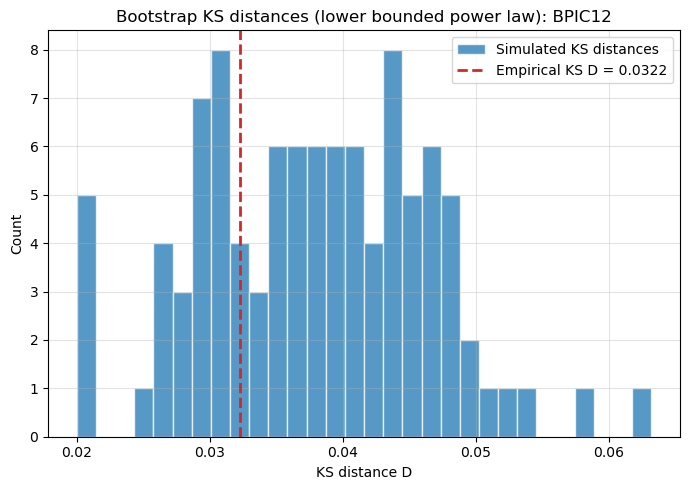

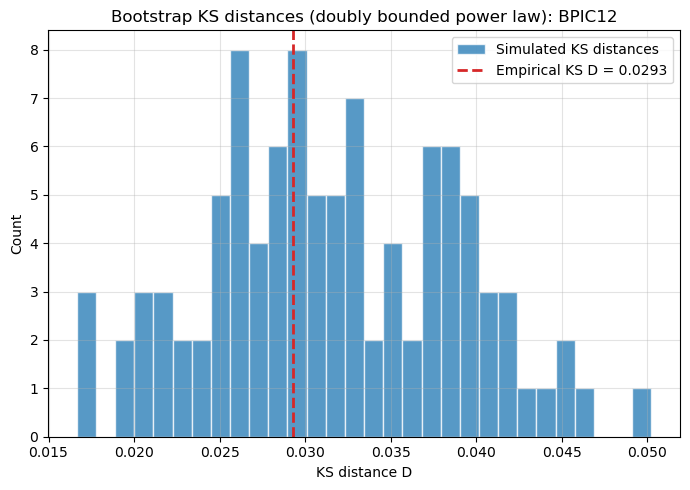

In [71]:
for name in DISTRIBUTION_NAMES:
    evaluation = evaluations.get(name)
    if evaluation is None:
        print(f"Skipping GOF histogram for {human_model_label(name)}: no fit available.")
        continue
    if not bool(evaluation.get("fit_valid", True)):
        print(
            f"Skipping GOF histogram for {human_model_label(name)}: "
            f"invalid fit ({evaluation.get('pathology_flags')})."
        )
        continue

    simulated = evaluation.get("simulated_distances")
    empirical_d = evaluation.get("empirical_d", evaluation.get("KS_D"))
    if simulated is None or len(simulated) == 0 or not np.isfinite(float(empirical_d)):
        print(f"Skipping GOF histogram for {human_model_label(name)}: no bootstrap distances.")
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(
        simulated,
        bins=30,
        color="C0",
        alpha=0.75,
        edgecolor="white",
        label="Simulated KS distances",
    )
    ax.axvline(
        float(empirical_d),
        color="C3",
        linestyle="--",
        linewidth=2.0,
        label=f"Empirical KS D = {float(empirical_d):.4f}",
    )
    ax.set_xlabel("KS distance D")
    ax.set_ylabel("Count")
    ax.set_title(
        f"Bootstrap KS distances ({human_model_label(name)}): {log_name}"
    )
    ax.legend()
    ax.grid(True, alpha=0.35)
    fig.tight_layout()
    plt.show()


## Summary classification

Each `run_clauset_pipeline` call already builds `summary_row` and classification.
Collect them below. `best_other_distribution` is the competing alternative with the most negative $R$.


In [72]:
summary_rows = []
classifications = {}
for name in DISTRIBUTION_NAMES:
    result = pipeline_results[name]
    summary = dict(result["summary_row"])
    classifications[name] = summary.get("classification")
    summary["distribution"] = name
    summary_rows.append(summary)
    print(f"{human_model_label(name)}: {classifications[name]}")

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


Final summary


,log_name,input_path,n_cases,n_variants,n_singletons,singleton_share,alpha,xmin,xmax,KS_D,...,n_success,n_failed,gof_kind,fit_valid,alpha_at_boundary,classification,best_other_distribution,distribution,doubly_bounded_exclude_head_variants,actual_excluded_variants
0,BPIC12,results/variants/BPIC12/attachments.csv.gz,13087,4366,3754,0.859826,3.000000,1.0,<NA>,0.999771,...,100,0,fixed_cutoffs,False,True,(1) full range power law invalid (alpha_at_par...,<NA>,full_range_power_law,NaN,NaN
1,BPIC12,results/variants/BPIC12/attachments.csv.gz,13087,4366,3754,0.859826,2.048576,4.0,<NA>,0.032244,...,100,0,fixed_cutoffs,True,False,(1) lower bounded power law plausible (p>=0.1)...,lognormal,lower_bounded_power_law,NaN,NaN
2,BPIC12,results/variants/BPIC12/attachments.csv.gz,13087,4366,3754,0.859826,2.064377,4.0,271.0,0.029278,...,100,0,selection_repeating,True,False,(1) doubly bounded power law plausible (p>=0.1...,truncated_power_law,doubly_bounded_power_law,2.0,2.0


full_range_power_law: (1) full range power law invalid (alpha_at_parameter_boundary, ks_d_pathological); (2) inconclusive
lower_bounded_power_law: (1) lower bounded power law plausible (p>=0.1); (2) preferred over alternatives
doubly_bounded_power_law: (1) doubly bounded power law plausible (p>=0.1); (2) preferred over alternatives

Model comparisons


,log_name,model_1,model_2,R,p,preferred_model,interpretation
0,BPIC12,lower_bounded_power_law,lognormal,-8.117011,0.315792,lognormal,inconclusive (lognormal numerically favored)
1,BPIC12,lower_bounded_power_law,exponential,294.405309,0.000629,lower_bounded_power_law,lower_bounded_power_law favored (distinguishable)
2,BPIC12,lower_bounded_power_law,stretched_exponential,2.577701,0.180238,lower_bounded_power_law,inconclusive (lower_bounded_power_law numerica...
3,BPIC12,lower_bounded_power_law,truncated_power_law,-0.000003,0.998052,truncated_power_law,inconclusive (truncated_power_law numerically ...
4,BPIC12,doubly_bounded_power_law,lognormal,-inf,NaN,unavailable,comparison failed
5,BPIC12,doubly_bounded_power_law,exponential,87.849250,0.000041,doubly_bounded_power_law,doubly_bounded_power_law favored (distinguisha...
6,BPIC12,doubly_bounded_power_law,stretched_exponential,1.184575,0.252968,doubly_bounded_power_law,inconclusive (doubly_bounded_power_law numeric...
7,BPIC12,doubly_bounded_power_law,truncated_power_law,-0.007656,0.901520,truncated_power_law,inconclusive (truncated_power_law numerically ...
